----------------------------------------
📊 DATA DIAGNOSTICS (Raw File)
   RED Max: 154676 | Mean: 129411
   IR  Max: 118455 | Mean: 107170
----------------------------------------
⚙️  Applying Manual Thresholds:
   RED Limit: > 132000
   IR  Limit: > 108000
✅ Success! Keeping 35697 valid samples.


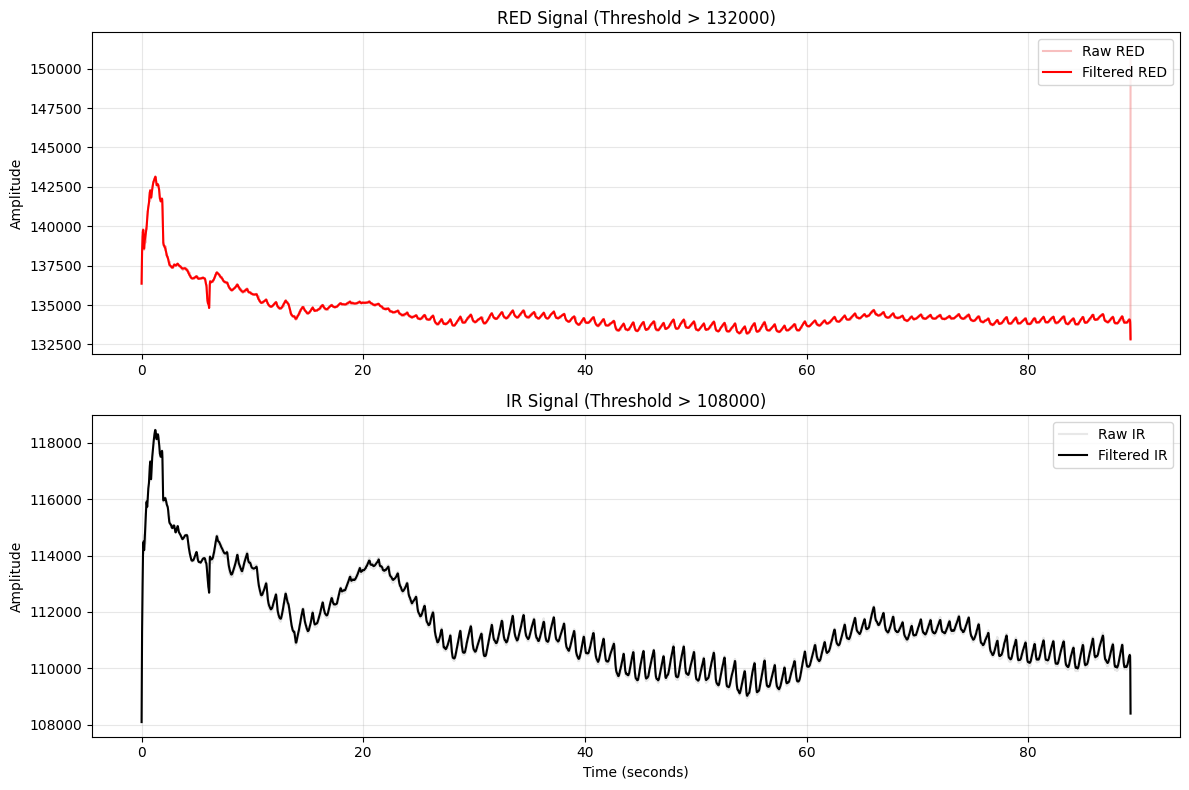

In [5]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt

# ==========================================
# 1. Configuration (MANUAL SETTINGS)
# ==========================================
FILENAME = '../Python_tools/ppg_data_B0001_rms01_0001_T21.csv'  
FS = 400.0                      # Sampling Frequency (Hz)
CUTOFF = 16.0                   # Low-Pass Cutoff (Hz)
ORDER = 4                       # Filter Order

# --- 🔧 SET YOUR MANUAL THRESHOLDS HERE ---
# Look at the "DIAGNOSTICS" output below to choose these!
# If your Max value is 100,000, try setting this to 20,000 (approx 20%)
THRESHOLD_RED = 132000         
THRESHOLD_IR  = 108000          

# ==========================================
# 2. Filter Function
# ==========================================
# ==========================================
# 2. Filter Function (UPDATED: Manual Kernel Tuning)
# ==========================================
def apply_precision_ppg_filter(raw_data, fs, cutoff, order, kernel_size=7):
    """
    Applies a Two-Stage Cleaning Pipeline with Manual Tuning.
    
    Parameters:
    - raw_data: The input signal array.
    - fs: Sampling frequency (Hz).
    - cutoff: Butterworth low-pass cutoff frequency (Hz).
    - order: Butterworth filter order.
    - kernel_size: Window size for Median Filter (MUST be an ODD number: 3, 5, 7...).
    """
    # Safety Check 1: Cannot filter extremely short segments
    if len(raw_data) < 30:
        return np.zeros_like(raw_data) 
    
    # Safety Check 2: Kernel size MUST be odd
    if kernel_size % 2 == 0:
        print(f"⚠️ Warning: kernel_size {kernel_size} is even! Force-adjusting to {kernel_size + 1}.")
        kernel_size += 1

    # --- STAGE 1: DESPIKING (The Median Filter) ---
    # Now uses the 'kernel_size' variable you provide
    despiked_data = signal.medfilt(raw_data, kernel_size=kernel_size)

    # --- STAGE 2: SMOOTHING (The Butterworth Filter) ---
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    sos = signal.butter(order, normal_cutoff, btype='low', analog=False, output='sos')
    
    # Feed the despiked data into the smoother
    filtered_signal = signal.sosfiltfilt(sos, despiked_data)
    
    return filtered_signal
# ==========================================
# 3. Main Pipeline
# ==========================================
try:
    df = pd.read_csv(FILENAME)
    
    # 1. Standardize Names
    df.columns = df.columns.str.strip().str.upper()
    rename_map = {
        'RED_VALUE': 'RED', 'IR_VALUE': 'IR',
        'RED VALUE': 'RED', 'IR VALUE': 'IR',
        'GLUCOSE_LABEL': 'LABEL'
    }
    df = df.rename(columns=rename_map)
    
    # 2. 📊 DIAGNOSTICS (LOOK AT THIS TO TUNE YOUR THRESHOLDS!)
    print("-" * 40)
    print("📊 DATA DIAGNOSTICS (Raw File)")
    print(f"   RED Max: {df['RED'].max()} | Mean: {df['RED'].mean():.0f}")
    print(f"   IR  Max: {df['IR'].max()} | Mean: {df['IR'].mean():.0f}")
    print("-" * 40)
    print(f"⚙️  Applying Manual Thresholds:")
    print(f"   RED Limit: > {THRESHOLD_RED}")
    print(f"   IR  Limit: > {THRESHOLD_IR}")

    # 3. Apply Separate Manual Thresholds
    # Logic: Keep row only if BOTH Red AND IR are above their specific limits
    mask = (df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)
    clean_df = df[mask].copy()

    # 4. Length Safety Check (Prevents Crash)
    if len(clean_df) < 50:
        print("\n❌ CRITICAL ERROR: Data too short after trimming!")
        print("   Your thresholds are likely too high.")
        print(f"   Samples Remaining: {len(clean_df)}")
        print("   👉 Try lowering THRESHOLD_RED and THRESHOLD_IR.")
    else:
        print(f"✅ Success! Keeping {len(clean_df)} valid samples.")

        # --- Filter & Plot ---
        red_filtered = apply_precision_ppg_filter(clean_df['RED'].values, FS, CUTOFF, ORDER)
        ir_filtered  = apply_precision_ppg_filter(clean_df['IR'].values, FS, CUTOFF, ORDER)
        
        t = np.arange(len(red_filtered)) / FS

        plt.figure(figsize=(12, 8))
        
        # Plot RED
        plt.subplot(2, 1, 1)
        plt.plot(t, clean_df['RED'].values, label='Raw RED', color='lightcoral', alpha=0.5)
        plt.plot(t, red_filtered, label=f'Filtered RED', color='red', linewidth=1.5)
        plt.title(f'RED Signal (Threshold > {THRESHOLD_RED})')
        plt.ylabel('Amplitude')
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)

        # Plot IR
        plt.subplot(2, 1, 2)
        plt.plot(t, clean_df['IR'].values, label='Raw IR', color='lightgray', alpha=0.5)
        plt.plot(t, ir_filtered, label=f'Filtered IR', color='black', linewidth=1.5)
        plt.title(f'IR Signal (Threshold > {THRESHOLD_IR})')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Amplitude')
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"❌ Error: {e}")

In [6]:
import scipy.stats as stats

# ==========================================
# 5. Signal Quality Check Function
# ==========================================
def analyze_signal_quality(signal_data, signal_name="Signal"):
    """
    Calculates Skewness, Kurtosis, and Perfusion Index (PI).
    Returns 'Pass' or 'Fail' based on Glucose Research Standards.
    """
    # 1. Statistical Features (From Paper 1)
    skew = stats.skew(signal_data)
    kurt = stats.kurtosis(signal_data)
    
    # 2. Perfusion Index (PI) Calculation (From Paper 3)
    # AC = Peak-to-Peak Amplitude
    # DC = Average Value (Offset)
    ac_component = np.max(signal_data) - np.min(signal_data)
    dc_component = np.mean(signal_data)
    
    # Avoid division by zero
    if dc_component == 0: 
        pi = 0
    else:
        pi = (ac_component / dc_component) * 100
    
    # 3. Quality Decision Logic
    # These thresholds are typical for good PPG
    quality_status = "✅ GOOD"
    if skew < 0.5:         quality_status = "⚠️ POOR (Too Symmetric/Noisy)"
    if pi < 0.2:           quality_status = "❌ BAD (Signal too weak)"
    
    # Print Report
    print(f"--- {signal_name} QUALITY REPORT ---")
    print(f"   Skewness: {skew:.4f} (Target: > 0.5)")
    print(f"   Kurtosis: {kurt:.4f} (Target: High is better)")
    print(f"   Perfusion Index: {pi:.4f}% (Target: > 0.5%)")
    print(f"   RESULT: {quality_status}")
    print("-" * 30)
    
    return skew, kurt, pi

# ==========================================
# INSERT THIS INTO YOUR MAIN PIPELINE
# (Put this right before the plt.show() command)
# ==========================================

print("\n🔍 Running Quality Analysis...")
# Analyze RED
analyze_signal_quality(red_filtered, "RED Filtered")

# Analyze IR
analyze_signal_quality(ir_filtered, "IR Filtered")


🔍 Running Quality Analysis...
--- RED Filtered QUALITY REPORT ---
   Skewness: 3.4657 (Target: > 0.5)
   Kurtosis: 14.9323 (Target: High is better)
   Perfusion Index: 7.6684% (Target: > 0.5%)
   RESULT: ✅ GOOD
------------------------------
--- IR Filtered QUALITY REPORT ---
   Skewness: 1.4458 (Target: > 0.5)
   Kurtosis: 2.6983 (Target: High is better)
   Perfusion Index: 9.2776% (Target: > 0.5%)
   RESULT: ✅ GOOD
------------------------------


(np.float64(1.445778169432429),
 np.float64(2.6983499966456312),
 np.float64(9.277638778793765))